# Doo — XGBoost 하이퍼파라미터 튜닝

기존 XGBoost 베이스라인을 Train 데이터 내부 5-fold 교차검증으로 튜닝합니다.

- 하이퍼파라미터 선택에는 `X_train`, `y_train`만 사용합니다.
- `X_val`, `y_val`은 튜닝 전후 최종 비교에만 사용합니다.
- Test 데이터는 최종 모델 확정 전까지 사용하지 않습니다.
- 팀 공통 시드 `random_state=42`를 유지합니다.

## 0. 실행 환경

XGBoost가 설치되어 있지 않으면 현재 노트북 커널에서 `%pip install xgboost`를 실행한 뒤 커널을 재시작합니다.

In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import xgboost

from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "data" / "preprocessed").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("data/preprocessed 폴더를 찾을 수 없음")
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "preprocessed"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]
X_val = pd.read_csv(DATA_DIR / "X_val.csv")
y_val = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

with open(DATA_DIR / "preprocessor.pkl", "rb") as file:
    preprocessor = pickle.load(file)

print("XGBoost version:", xgboost.__version__)
print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

XGBoost version: 3.3.0
X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


## 1. 평가 함수와 베이스라인 정의

In [2]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
)
from xgboost import XGBClassifier

xgboost_baseline_model = XGBClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=3, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    objective="binary:logistic", eval_metric="logloss",
    random_state=42, n_jobs=1, verbosity=0,
)

xgboost_baseline_model.fit(X_train, y_train)
xgboost_baseline_val_pred = xgboost_baseline_model.predict(X_val)
xgboost_baseline_val_proba = xgboost_baseline_model.predict_proba(X_val)[:, 1]

def evaluate_binary_model(model_name, y_true, pred, proba):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, pred),
        "recall": recall_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
    }

display(pd.DataFrame([evaluate_binary_model(
    "XGBoost baseline", y_val, xgboost_baseline_val_pred, xgboost_baseline_val_proba
)]).style.format("{:.3f}", subset=pd.IndexSlice[:, "accuracy":]))

,model,accuracy,recall,precision,f1,roc_auc
0,XGBoost baseline,0.707,0.728,0.694,0.711,0.766


## 2. RandomizedSearchCV 설정

Train 데이터를 5개 Fold로 나누어 후보 조합을 비교합니다. 탐색 범위는 작은 데이터에서 과적합을 줄이도록 제한했습니다. `roc_auc`를 튜닝 기준으로 사용하고, 최종 임계값은 Validation에서 별도로 확인합니다.

In [3]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

xgboost_param_distributions = {
    "n_estimators": [150, 250, 350, 500],
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "max_depth": [2, 3, 4],
    "min_child_weight": [3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 3, 5],
}

xgboost_tuning_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
)

xgboost_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
        verbosity=0,
    ),
    param_distributions=xgboost_param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=xgboost_tuning_cv,
    refit=True,
    return_train_score=True,
    random_state=42,
    n_jobs=1,
)

xgboost_search.fit(X_train, y_train)
print("튜닝 완료")

튜닝 완료


## 3. 최적 설정과 교차검증 결과 확인

In [4]:
print("Best CV ROC-AUC:", round(xgboost_search.best_score_, 4))
print("Best parameters:")
display(pd.Series(xgboost_search.best_params_, name="value"))

xgboost_search_results_df = (
    pd.DataFrame(xgboost_search.cv_results_)
    .sort_values("rank_test_score")
    [["rank_test_score", "mean_test_score", "std_test_score", "mean_train_score", "params"]]
    .head(10)
)
display(xgboost_search_results_df.style.format({
    "mean_test_score": "{:.4f}", "std_test_score": "{:.4f}",
    "mean_train_score": "{:.4f}",
}))

Best CV ROC-AUC: 0.7778
Best parameters:


subsample             0.70
reg_lambda            3.00
reg_alpha             0.10
n_estimators        250.00
min_child_weight      3.00
max_depth             4.00
learning_rate         0.02
colsample_bytree      0.90
Name: value, dtype: float64

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
4,1,0.7778,0.0177,0.8540,"{'subsample': 0.7, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 250, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.9}"
13,2,0.7758,0.0203,0.8217,"{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 250, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.02, 'colsample_bytree': 0.7}"
15,3,0.7757,0.0199,0.8150,"{'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.02, 'colsample_bytree': 0.8}"
8,4,0.7750,0.0198,0.8179,"{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 150, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.08, 'colsample_bytree': 0.9}"
17,5,0.7746,0.0175,0.8541,"{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 350, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.8}"
0,6,0.7746,0.0191,0.8087,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 350, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.02, 'colsample_bytree': 1.0}"
1,7,0.7745,0.0186,0.8376,"{'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.02, 'colsample_bytree': 0.7}"
18,8,0.7745,0.0195,0.8204,"{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 150, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 1.0}"
5,9,0.7738,0.0176,0.8707,"{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 350, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.8}"
12,10,0.7735,0.0210,0.8149,"{'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.5, 'n_estimators': 350, 'min_child_weight': 10, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.7}"


## 4. Validation에서 튜닝 전후 비교

In [5]:
xgboost_tuned_model = xgboost_search.best_estimator_
xgboost_tuned_train_pred = xgboost_tuned_model.predict(X_train)
xgboost_tuned_val_pred = xgboost_tuned_model.predict(X_val)
xgboost_tuned_val_proba = xgboost_tuned_model.predict_proba(X_val)[:, 1]

xgboost_before_after_df = pd.DataFrame([
    {
        "model": "Baseline",
        "train_accuracy": accuracy_score(y_train, xgboost_baseline_model.predict(X_train)),
        "val_accuracy": accuracy_score(y_val, xgboost_baseline_val_pred),
        "recall": recall_score(y_val, xgboost_baseline_val_pred),
        "precision": precision_score(y_val, xgboost_baseline_val_pred),
        "f1": f1_score(y_val, xgboost_baseline_val_pred),
        "roc_auc": roc_auc_score(y_val, xgboost_baseline_val_proba),
    },
    {
        "model": "Tuned",
        "train_accuracy": accuracy_score(y_train, xgboost_tuned_train_pred),
        "val_accuracy": accuracy_score(y_val, xgboost_tuned_val_pred),
        "recall": recall_score(y_val, xgboost_tuned_val_pred),
        "precision": precision_score(y_val, xgboost_tuned_val_pred),
        "f1": f1_score(y_val, xgboost_tuned_val_pred),
        "roc_auc": roc_auc_score(y_val, xgboost_tuned_val_proba),
    },
])
xgboost_before_after_df["train_val_gap"] = xgboost_before_after_df["train_accuracy"] - xgboost_before_after_df["val_accuracy"]
display(xgboost_before_after_df.style.format({column: "{:.3f}" for column in xgboost_before_after_df.columns if column != "model"}))

,model,train_accuracy,val_accuracy,recall,precision,f1,roc_auc,train_val_gap
0,Baseline,0.756,0.707,0.728,0.694,0.711,0.766,0.049
1,Tuned,0.755,0.703,0.728,0.688,0.708,0.767,0.052


## 5. 튜닝 모델 임계값 비교

In [6]:
xgboost_tuned_threshold_rows = []
for threshold in np.arange(0.25, 0.71, 0.05):
    threshold_pred = (xgboost_tuned_val_proba >= threshold).astype(int)
    xgboost_tuned_threshold_rows.append({
        "threshold": threshold,
        "recall": recall_score(y_val, threshold_pred),
        "precision": precision_score(y_val, threshold_pred, zero_division=0),
        "f1": f1_score(y_val, threshold_pred, zero_division=0),
        "predicted_churn_count": int(threshold_pred.sum()),
    })
xgboost_tuned_threshold_df = pd.DataFrame(xgboost_tuned_threshold_rows)
display(xgboost_tuned_threshold_df.style.format({
    "threshold": "{:.2f}", "recall": "{:.3f}",
    "precision": "{:.3f}", "f1": "{:.3f}",
}))

xgboost_tuned_candidates = xgboost_tuned_threshold_df[xgboost_tuned_threshold_df["recall"] >= 0.80]
if xgboost_tuned_candidates.empty:
    print("Recall 0.80 이상 후보가 없습니다.")
else:
    xgboost_tuned_best_threshold = xgboost_tuned_candidates.loc[xgboost_tuned_candidates["f1"].idxmax()]
    print("선택 임계값")
    display(xgboost_tuned_best_threshold.to_frame("selected_value"))

,threshold,recall,precision,f1,predicted_churn_count
0,0.25,0.932,0.598,0.729,665
1,0.30,0.904,0.620,0.735,623
2,0.35,0.871,0.635,0.734,586
3,0.40,0.836,0.653,0.733,547
4,0.45,0.787,0.669,0.723,502
5,0.50,0.728,0.688,0.708,452
6,0.55,0.658,0.701,0.679,401
7,0.60,0.585,0.712,0.643,351
8,0.65,0.468,0.735,0.572,272
9,0.70,0.370,0.763,0.498,207


선택 임계값


,selected_value
threshold,0.300000
recall,0.903981
precision,0.619583
f1,0.735238
predicted_churn_count,623.000000


## 6. 튜닝 모델 피처 중요도

,feature,importance
0,avg_days_between_orders,0.309048
1,net_revenue,0.119196
2,frequency,0.108747
3,recency_days,0.103298
4,distinct_products,0.079898
5,recent_activity_ratio,0.069001
6,has_return,0.066018
7,tenure_days,0.063642
8,is_low_value,0.059209
9,is_uk,0.021944


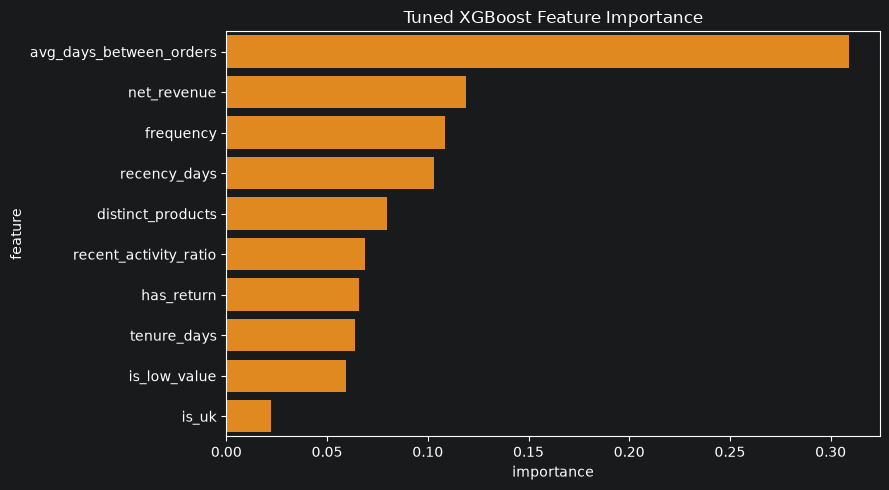

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

xgboost_tuned_importance_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": xgboost_tuned_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(xgboost_tuned_importance_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=xgboost_tuned_importance_df, x="importance", y="feature", color="darkorange")
plt.title("Tuned XGBoost Feature Importance")
plt.tight_layout()
plt.show()

## 7. 해석 및 다음 단계

튜닝 모델의 Validation 점수가 좋아졌더라도 `train_val_gap`이 크게 증가하면 과적합 가능성이 있습니다. 최종 설정은 Train 교차검증 점수와 Validation 결과를 함께 보고 결정합니다. 이 노트북에서는 Test 데이터를 사용하지 않았으며, 팀 합의 후 최종 모델에서만 한 번 평가합니다.